#### Importing Python Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import statsmodels.api as sm

Part A)

In [3]:
#Loading of the Dataset
data = pd.read_csv('auto.csv')
X = data['displacement']
y = data['mpg']
print(X.head(10))
print(y.head(10))

0    307.0
1    350.0
2    318.0
3    304.0
4    302.0
5    429.0
6    454.0
7    440.0
8    455.0
9    390.0
Name: displacement, dtype: float64
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
5    15.0
6    14.0
7    14.0
8    14.0
9    15.0
Name: mpg, dtype: float64


Part B)

In [4]:
#Defines the function to split the data into training and testing sets
def data_split(X, y):
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42) #Splitting 60/40 Train/Test
    x_train = x_train.values.reshape(-1,1) #Reshaping the series to a 2D array for input into the model
    y_train = y_train.values.reshape(-1,1)
    x_test = x_test.values.reshape(-1,1)
    y_test = y_test.values.reshape(-1,1)
    return x_train, x_test, y_train, y_test

In [5]:
x_train, x_test, y_train, y_test = data_split(X, y) #Splitting the data

Part C)

In [6]:
#Trains the OLS model using the training data
def train_ols_model(x_train, y_train):
    x_train_cons= sm.add_constant(x_train)
    model = sm.OLS(y_train, x_train_cons) #Using Ordinary Least Squares regression similar to sci-kit learn's LinearRegression
    result = model.fit()
    return result

In [7]:
model = train_ols_model(x_train, y_train)
print("Intercept and coefficients/Slope:", model.params)

Intercept and coefficients/Slope: [36.30988365 -0.06387534]


Part D)

In [8]:
#Evaluates the model using the test data, prints the summary table, and returns R^2 and MSE
def evaluate_model(model, x_test, y_test):
    x_test_cons = sm.add_constant(x_test)
    y_pred = model.predict(x_test_cons)
    R2 = r2_score(y_test, y_pred)
    err = mean_squared_error(y_test, y_pred)
    print("\nSummary Table from Training")
    print("Model MSE on Training: ", model.mse_resid)
    print(model.summary())
    return R2, err

In [9]:
R2, err = evaluate_model(model, x_test, y_test)
print("Model R^2 Score on Test: ", R2)
print("Model MSE on Test: ", err)



Summary Table from Training
Model MSE on Training:  21.155905187632094
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     491.7
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.47e-59
Time:                        12:35:25   Log-Likelihood:                -691.05
No. Observations:                 235   AIC:                             1386.
Df Residuals:                     233   BIC:                             1393.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Part E)

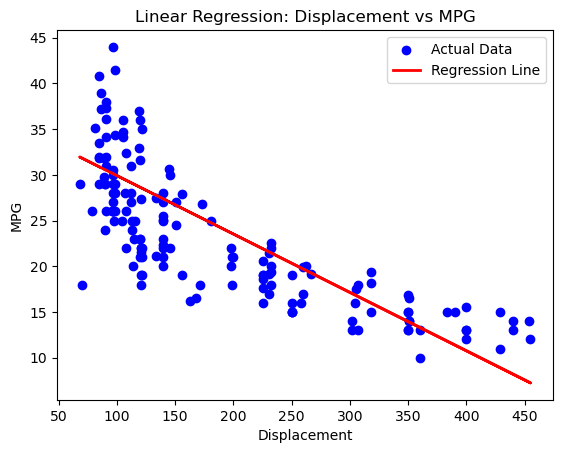

In [10]:
#Plotting the results
y_pred = model.predict(sm.add_constant(x_test)) #Predicting the values for the test set for plotting
plt.scatter(x_test, y_test, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Linear Regression: Displacement vs MPG')
plt.legend()
plt.savefig("Figure_Displacement.png", dpi=400)
plt.show()


Part f)

#### Disclaimer
-Output is truncated for easier viewing, expand to see all details.


Summary Table from Training
Model MSE on Training:  21.155905187632094
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     491.7
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.47e-59
Time:                        12:35:25   Log-Likelihood:                -691.05
No. Observations:                 235   AIC:                             1386.
Df Residuals:                     233   BIC:                             1393.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

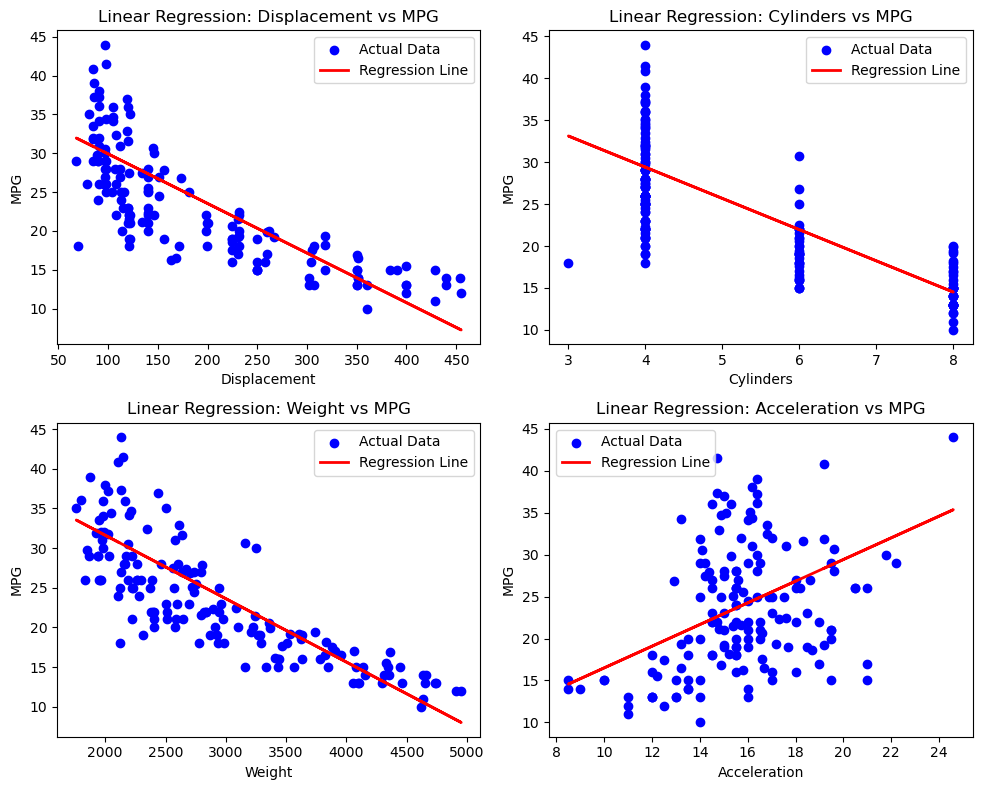

In [11]:

#This splits the data, fits the model, stores all performance, and plots all four features in a 2x2 grid of subplots

scores = {} # This is for tracking the model's performance for comparison in Part E
plt.figure(figsize=(10,8))
for idx, feature in enumerate(['displacement','cylinders', 'weight', 'acceleration'], start=1):
    X_feat = data[feature]
    x_train, x_test, y_train, y_test = data_split(X_feat, y)
    model=train_ols_model(x_train, y_train) #Trains model for each feature
    R2, err = evaluate_model(model, x_test, y_test)
    print(f"Feature: {feature.capitalize()}") #For Labeling
    scores[feature] = (R2, err, model.params[1], model.params[0]) #Stores R2, MSE, Coefficient, Intercept
    
    y_pred = model.predict(sm.add_constant(x_test)) #For Plotting
    sub=plt.subplot(2,2, idx)
    sub.scatter(x_test, y_test, color='blue', label='Actual Data')
    sub.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
    sub.set_xlabel(feature.capitalize())
    sub.set_ylabel('MPG')
    sub.set_title(f'Linear Regression: {feature.capitalize()} vs MPG')
    sub.legend()
plt.tight_layout()
plt.savefig("Figure_4Feats.png", dpi=400)
plt.show()
    

Part G)

Ranking all four models

In [12]:
errors = {}
r2 = {}
for feature, (R2, err, coef, intercept) in scores.items():
    errors[feature] = err
    r2[feature]= R2
sorted_errors = sorted(errors.items(), key=lambda x: x[1]) # Sort by MSE (value at index 1)
sorted_R2 = sorted(r2.items(), key=lambda x: x[1], reverse=True) # Sort by R2 (value at index 1) in descending order
print("\n=== FINAL RANKING on Test Data ===")
print("Model Ranking by MSE (Lowest to Highest):")
for i, (feature, mse) in enumerate(sorted_errors, 1):
    print(f"{i}. {feature.capitalize()}: MSE = {mse}")
print("Model Ranking by R2 (Highest to Lowest):")
for i, (feature, R2) in enumerate(sorted_R2, 1):
    print(f"{i}. {feature.capitalize()}: R2 = {R2}")


=== FINAL RANKING on Test Data ===
Model Ranking by MSE (Lowest to Highest):
1. Weight: MSE = 19.120569073315192
2. Displacement: MSE = 22.866365371406957
3. Cylinders: MSE = 25.20273194028525
4. Acceleration: MSE = 47.34592777273952
Model Ranking by R2 (Highest to Lowest):
1. Weight: R2 = 0.6462574933480636
2. Displacement: R2 = 0.5769579151391823
3. Cylinders: R2 = 0.5337336699107166
4. Acceleration: R2 = 0.12407067457712773
